In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [116]:
df_test = pd.read_csv('C:\\Users\\Student\\INTRO_ML\\challenge1_test.csv')
df_train = pd.read_csv('C:\\Users\\Student\\INTRO_ML\\challenge1_train.csv')


In [118]:
df_train.head()

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,2,925,1.0,0,116,47.6160,-122.3275,housing/rent/apartment,Thumbnail,WA
1,3,2475,1.0,0,130,40.7629,-73.9885,housing/rent/apartment,Thumbnail,NY
2,5,1695,1.0,0,190,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
3,6,1560,1.0,1,200,35.0847,-77.0609,housing/rent/apartment,Thumbnail,NC
4,7,1560,1.0,1,200,35.0960,-77.0272,housing/rent/apartment,Thumbnail,NC


In [119]:
df_test.head()

,ID,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,1,1.0,0,107,38.8910,-77.0816,housing/rent/apartment,Thumbnail,VA
1,4,1.0,0,138,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
2,9,1.0,1,200,38.1172,-122.2313,housing/rent/apartment,Thumbnail,CA
3,11,1.0,1,200,35.2016,-80.8124,housing/rent/apartment,Thumbnail,NC
4,13,1.0,1,200,33.5178,-112.0848,housing/rent/apartment,Thumbnail,AZ


In [120]:
df_train.tail()

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
7393,9858,8345,4.0,8,4900,43.0724,-89.4003,housing/rent/apartment,Thumbnail,WI
7394,9860,3200,5.0,6,5199,33.4072,-84.4523,housing/rent/apartment,Thumbnail,GA
7395,9861,4500,5.0,4,5407,44.8653,-93.4749,housing/rent/apartment,Thumbnail,MN
7396,9862,6900,5.0,5,5700,28.1253,-82.4468,housing/rent/apartment,Thumbnail,FL
7397,9863,3000,4.0,6,5921,37.0835,-113.5823,housing/rent/apartment,Thumbnail,UT


In [121]:
df_test.tail()

,ID,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
2462,9855,4.5,6,4733,32.7876,-117.1265,housing/rent/apartment,Thumbnail,CA
2463,9856,4.0,5,4736,39.9974,-82.9829,housing/rent/apartment,Thumbnail,OH
2464,9859,3.5,5,4970,39.8228,-105.1107,housing/rent/apartment,Thumbnail,CO
2465,9864,4.0,5,6300,44.9000,-93.3233,housing/rent/apartment,Thumbnail,MN
2466,9865,1.0,1,880,34.0072,-84.0034,housing/rent/apartment,No,GA


In [122]:
print("The shape of the training dataset is: ", df_train.shape, "\nthe shape of the testing dataset is: ", df_test.shape)

The shape of the training dataset is:  (7398, 10) 
the shape of the testing dataset is:  (2467, 9)


In [123]:
df_test.columns.tolist()

['ID',
 'bathrooms',
 'bedrooms',
 'square_feet',
 'latitude',
 'longitude',
 'category',
 'has_photo',
 'state']

In [124]:
df_train.columns.tolist()

['ID',
 'price',
 'bathrooms',
 'bedrooms',
 'square_feet',
 'latitude',
 'longitude',
 'category',
 'has_photo',
 'state']

In [125]:
df_test.describe().round(2)

,ID,bathrooms,bedrooms,square_feet,latitude,longitude
count,2467.00,2467.00,2467.00,2467.00,2467.00,2467.00
mean,4869.79,1.37,1.74,931.68,37.82,-95.22
std,2855.38,0.59,0.93,507.04,5.50,15.97
min,1.00,1.00,0.00,107.00,21.32,-157.84
25%,2377.00,1.00,1.00,642.00,33.74,-104.91
50%,4814.00,1.00,2.00,800.00,38.78,-93.67
75%,7301.50,2.00,2.00,1088.50,41.58,-82.86
max,9865.00,5.00,6.00,6300.00,61.59,-70.19


In [126]:
df_train.describe().round(2)

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude
count,7398.00,7398.00,7398.00,7398.00,7398.00,7398.00,7398.00
mean,4954.08,1462.81,1.38,1.74,940.94,37.65,-94.41
std,2845.31,821.58,0.60,0.94,502.25,5.52,15.72
min,2.00,200.00,1.00,0.00,116.00,21.32,-158.02
25%,2495.25,949.00,1.00,1.00,650.00,33.60,-98.53
50%,4972.50,1273.50,1.00,2.00,807.50,38.77,-93.65
75%,7435.75,1695.00,2.00,2.00,1100.00,41.35,-81.64
max,9863.00,8800.00,7.00,9.00,5921.00,61.59,-70.35


In [127]:
df_test.columns.tolist()

['ID',
 'bathrooms',
 'bedrooms',
 'square_feet',
 'latitude',
 'longitude',
 'category',
 'has_photo',
 'state']

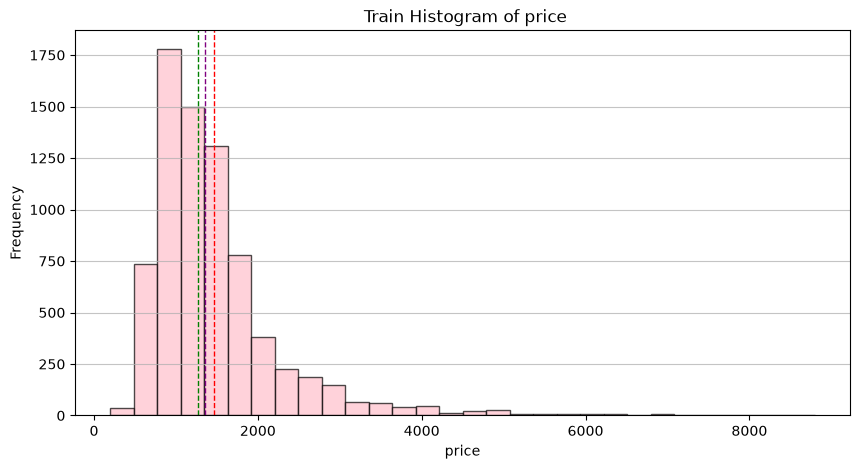

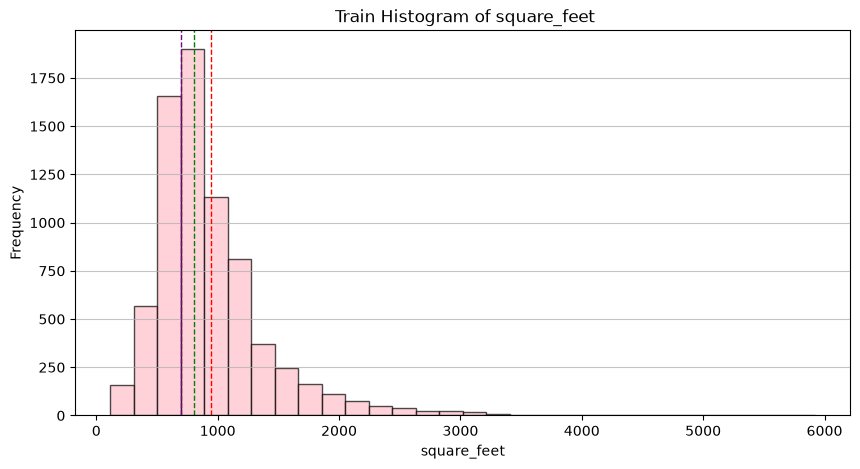

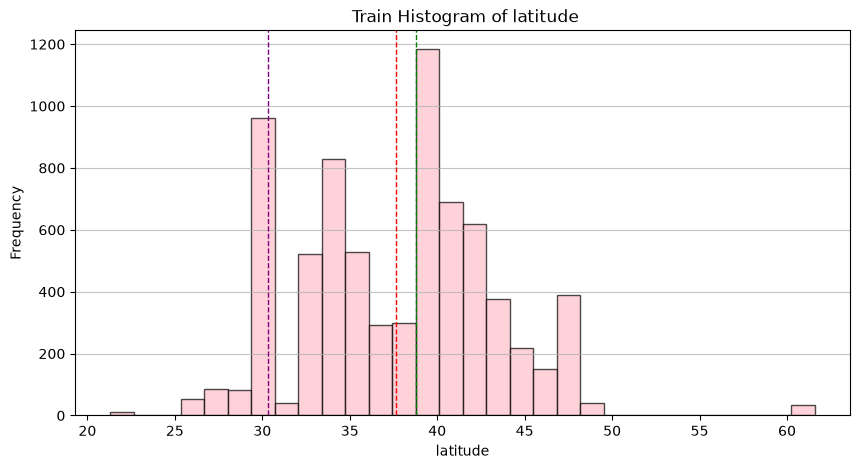

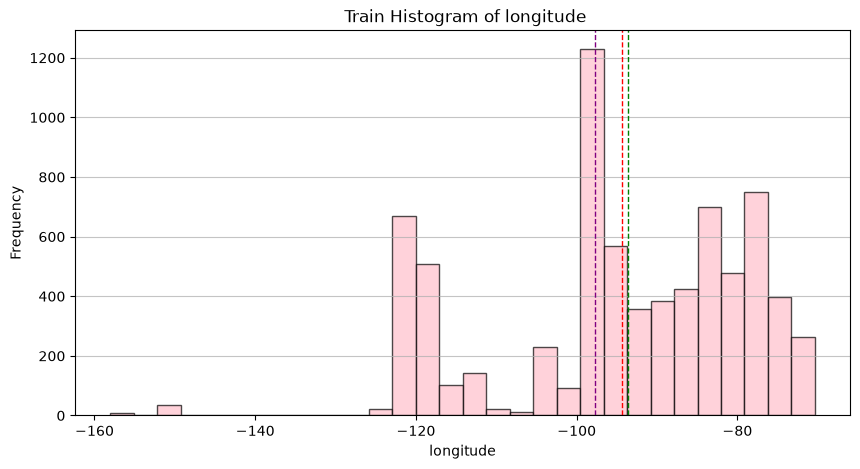

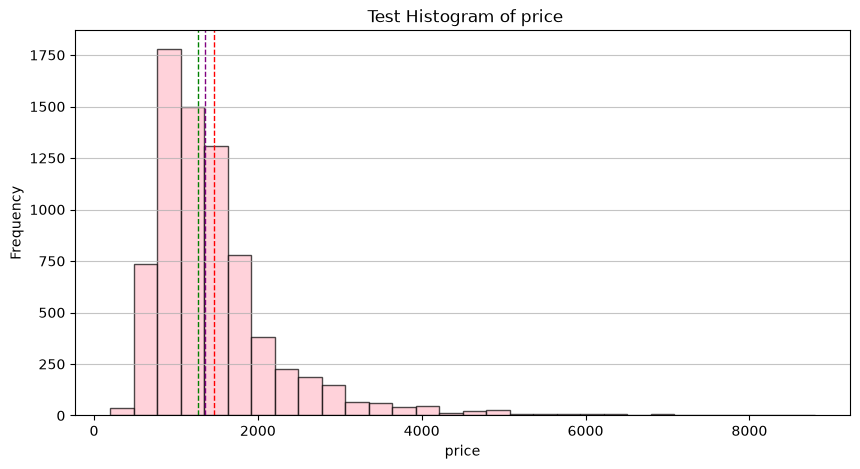

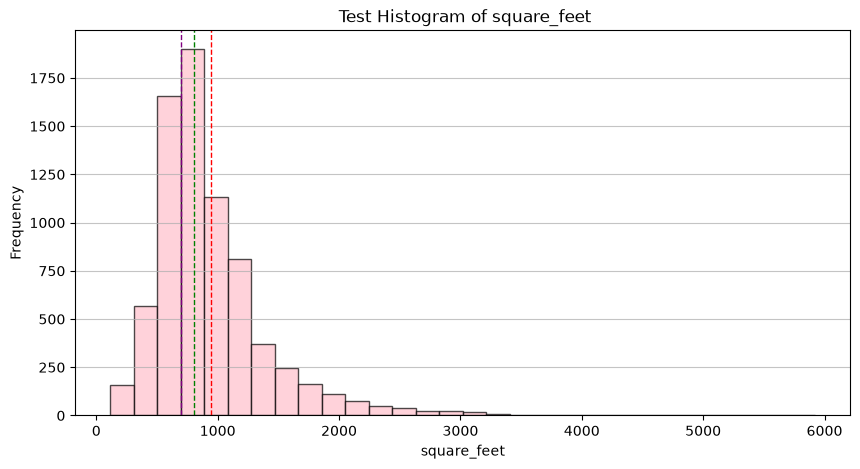

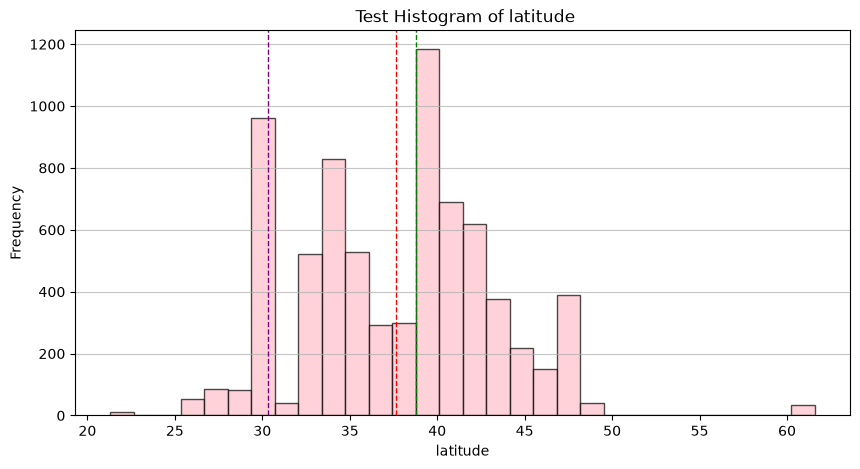

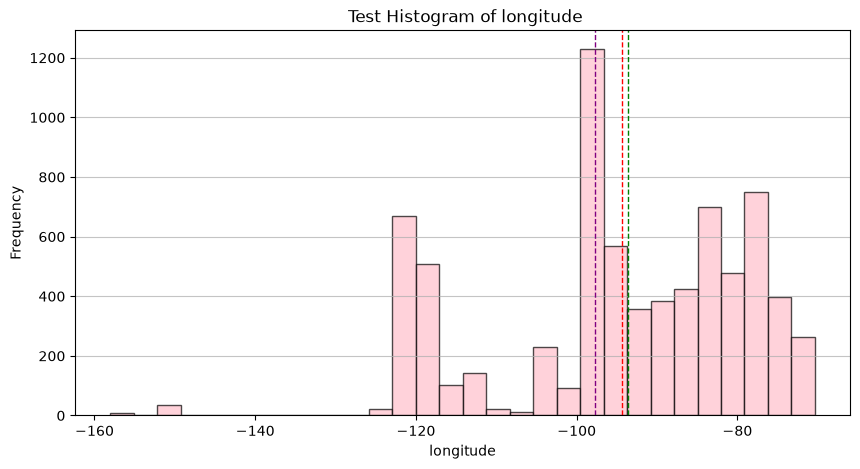

In [128]:
excluded_cols = (
    'ID',
    'bathrooms',
    'bedrooms',
    'category',
    'has_photo',
    'state'
)

for col in df_train.columns:
    if col in excluded_cols:
        continue
    plt.figure(figsize=(10, 5))
    plt.hist(df_train[col], bins=30, alpha=0.7, color='pink', edgecolor='black')
    plt.title(f' Train Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    axvline = df_train[col].mean()
    plt.axvline(axvline, color='red', linestyle='dashed', linewidth=1)
    axvline = df_train[col].median()
    plt.axvline(axvline, color='green', linestyle='dashed', linewidth=1)
    axvline = df_train[col].mode()[0]
    plt.axvline(axvline, color='purple', linestyle='dashed', linewidth=1)
    plt.grid(axis='y', alpha=0.75)
    plt.show()
for col in df_train.columns:
    if col in excluded_cols:
        continue
    plt.figure(figsize=(10, 5))
    plt.hist(df_train[col], bins=30, alpha=0.7, color='pink', edgecolor='black')
    plt.title(f' Test Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    axvline = df_train[col].mean()
    plt.axvline(axvline, color='red', linestyle='dashed', linewidth=1)
    axvline = df_train[col].median()
    plt.axvline(axvline, color='green', linestyle='dashed', linewidth=1)
    axvline = df_train[col].mode()[0]
    plt.axvline(axvline, color='purple', linestyle='dashed', linewidth=1)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

<Axes: xlabel='state'>

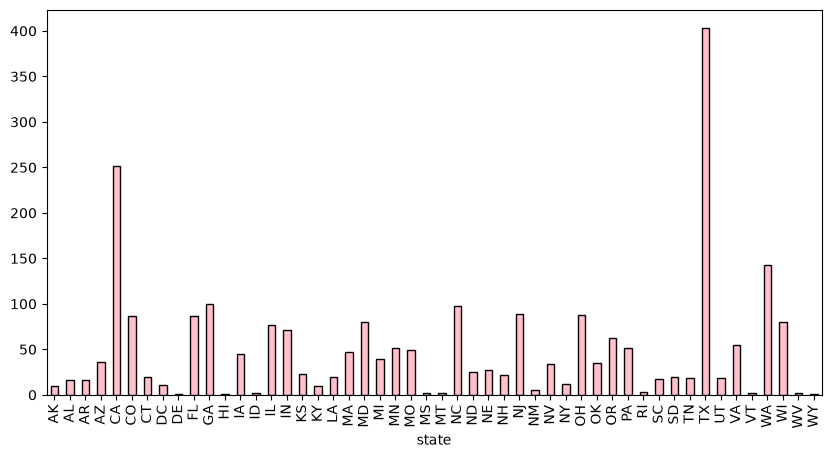

In [129]:
df_test.groupby('state').size().plot(kind='bar', figsize=(10, 5), color='pink', edgecolor='black')

<Axes: xlabel='state'>

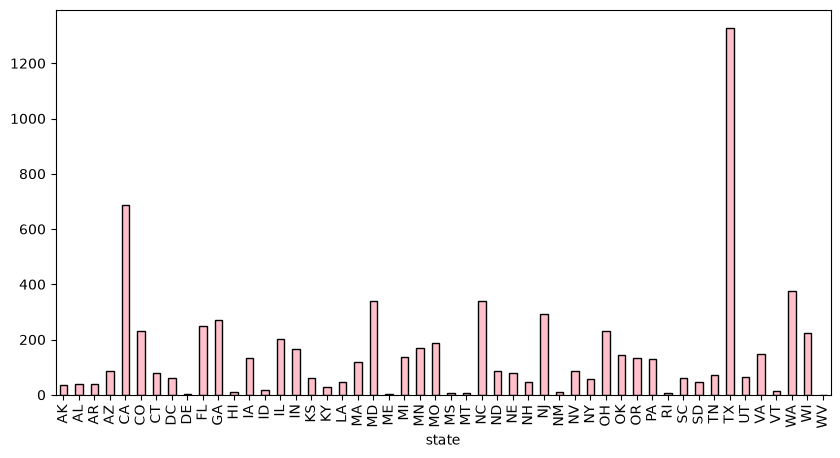

In [130]:
df_train.groupby('state').size().plot(kind='bar', figsize=(10, 5), color='pink', edgecolor='black')

In [131]:
df_train.head(5)

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,2,925,1.0,0,116,47.6160,-122.3275,housing/rent/apartment,Thumbnail,WA
1,3,2475,1.0,0,130,40.7629,-73.9885,housing/rent/apartment,Thumbnail,NY
2,5,1695,1.0,0,190,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
3,6,1560,1.0,1,200,35.0847,-77.0609,housing/rent/apartment,Thumbnail,NC
4,7,1560,1.0,1,200,35.0960,-77.0272,housing/rent/apartment,Thumbnail,NC


### Data Analysis 
* price is the target for the prediction 

In [132]:
# columntransformer: -> num_pipeline -> genre -> simpleimputer->standard scaler/onehot encoder -> decion tree classifier

In [117]:
df_1 = pd.read_csv('C:\\Users\\Student\\INTRO_ML\\challenge1_train.csv')
df_2 = pd.read_csv('C:\\Users\\Student\\INTRO_ML\\challenge1_test.csv')

if 'price' not in df_2.columns: 
    df_2['price']=0
df = pd.concat([df_1, df_2], axis = 0)
df = df.set_index('ID')



In [138]:
df_null =  df[df.isnull().sum()[df.isnull().sum()>0].index]

In [144]:
df.info()

<class 'pandas.DataFrame'>
Index: 9865 entries, 2 to 9865
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        9865 non-null   int64  
 1   bathrooms    9865 non-null   float64
 2   bedrooms     9865 non-null   int64  
 3   square_feet  9865 non-null   int64  
 4   latitude     9865 non-null   float64
 5   longitude    9865 non-null   float64
 6   category     9865 non-null   str    
 7   has_photo    9865 non-null   str    
 8   state        9865 non-null   str    
dtypes: float64(3), int64(3), str(3)
memory usage: 770.7 KB


In [ ]:
df['category'].value_counts() 

category
housing/rent/apartment     9862
housing/rent/home             2
housing/rent/short_term       1
Name: count, dtype: int64

In [149]:
df['has_photo'].value_counts() # one hot encoding since it has three categories  and no need for precedence 

has_photo
Thumbnail    8774
Yes           908
No            183
Name: count, dtype: int64

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns


In [150]:
df['state'].value_counts() # one hot encoding since it has many categories and no need for precedence 

state
TX    1730
CA     940
WA     518
NC     438
MD     421
NJ     383
GA     371
FL     336
OH     320
CO     317
WI     302
IL     280
MO     238
IN     236
MN     221
VA     204
OR     197
PA     182
IA     179
OK     178
MI     176
MA     166
AZ     123
NV     120
ND     112
NE     105
CT      98
TN      91
UT      84
KS      83
SC      77
DC      73
NH      70
NY      68
LA      66
SD      66
AL      56
AR      56
AK      44
KY      40
ID      21
VT      16
NM      14
RI      11
HI      11
MS       9
MT       7
DE       5
WV       3
ME       2
WY       1
Name: count, dtype: int64

In [ ]:
# column_to_encode = ["has_photo", "state"]

# encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# train_encoded = encoder.fit_transform(df_train[column_to_encode])

# test_encoded = encoder.transform(df_test[column_to_encode])

# encoded_names = encoder.get_feature_names_out(column_to_encode)

# train_encoded_df = pd.DataFrame(
#     train_encoded,
#     columns=encoded_names,
#     index=df_train.index
# )

# test_encoded_df = pd.DataFrame(
#     test_encoded,
#     columns=encoded_names,
#     index=df_test.index
# )

# train_final = pd.concat(
#     [df_train.drop(columns=column_to_encode), train_encoded_df],
#     axis=1
# )

# test_final = pd.concat(
#     [df_test.drop(columns=column_to_encode), test_encoded_df],
#     axis=1
# )

# train_final.to_csv("challenge1_train_encoded.csv", index=False)

# test_final.to_csv("challenge1_test_encoded.csv", index=False)

-after i push the new csvs i will comment this out

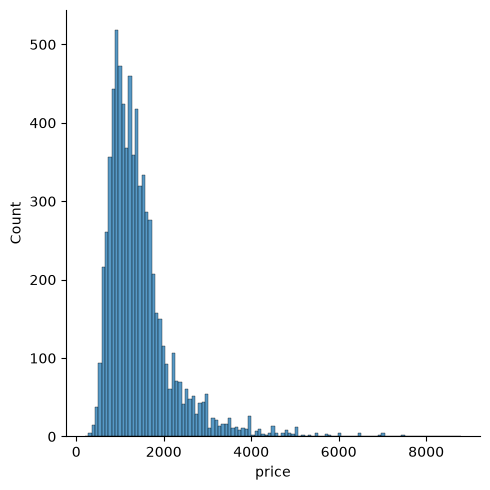

In [163]:
sns.displot(df_train['price'])

<Axes: xlabel='square_feet', ylabel='price'>

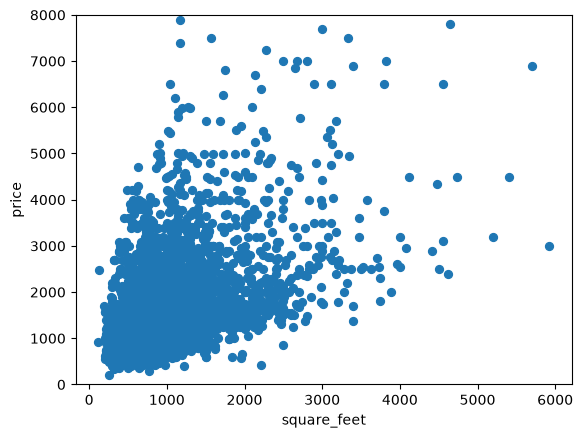

In [164]:
data = pd.concat([df_train['price'], df_train['square_feet']], axis=1)
data.plot.scatter(x='square_feet', y='price', ylim=(0,8000), s=32)

<Axes: >

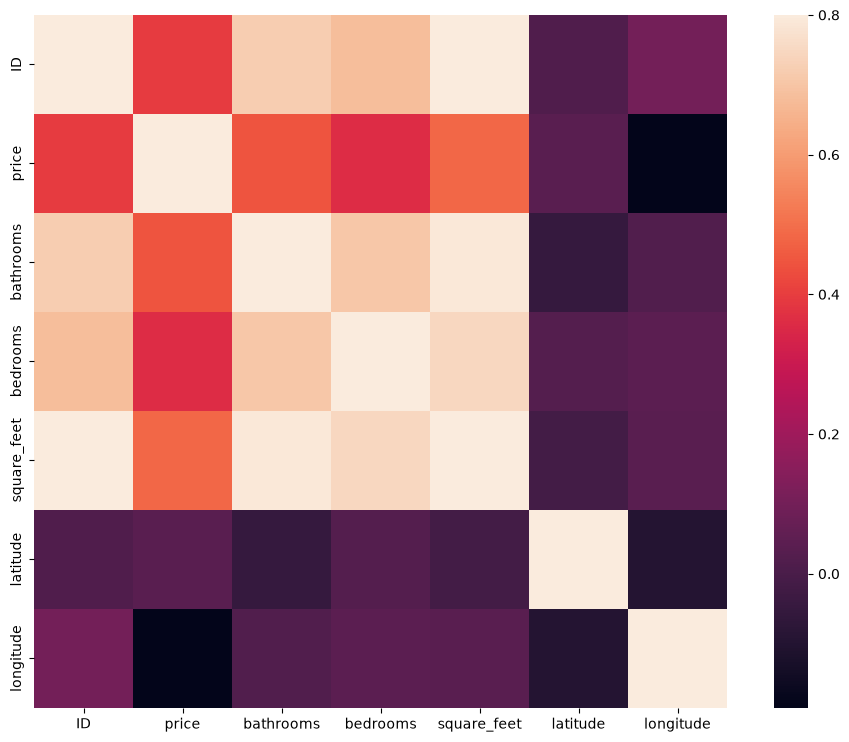

In [166]:
corr_mat = df_train.select_dtypes(include=['number']).corr()
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr_mat, vmax=0.8, square=True)